# Seller Churn Prediction Model & Explainability

This notebook evaluates the XGBoost classifier on the 2018 test period, calculates the actual revenue protected, and uses SHAP to explain exactly *why* the model flagged specific sellers.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import os

# Hack to bypass PyTorch DLL initialization failure on Windows when importing shap
import sys
from unittest.mock import MagicMock
sys.modules['torch'] = MagicMock()
import shap

plt.style.use('seaborn-v0_8-darkgrid')

# Load the scored test dataset and SHAP values generated by ml_models/seller_churn_classifier.py
scored_df = pd.read_parquet('../data/processed/test_scored.parquet')
shap_values = np.load('../data/models/test_shap_values.npy')

model = xgb.XGBClassifier()
model.load_model('../data/models/seller_churn_model.json')

features = [c for c in scored_df.columns if c not in ["seller_id", "seller_state", "observation_date", "churned", "churn_probability", "risk_tier"]]
print("Data and model artifacts loaded successfully.")

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


Data and model artifacts loaded successfully.


## 1. Global Feature Importance (SHAP Beeswarm)

Which behaviors drive seller churn across the entire platform?

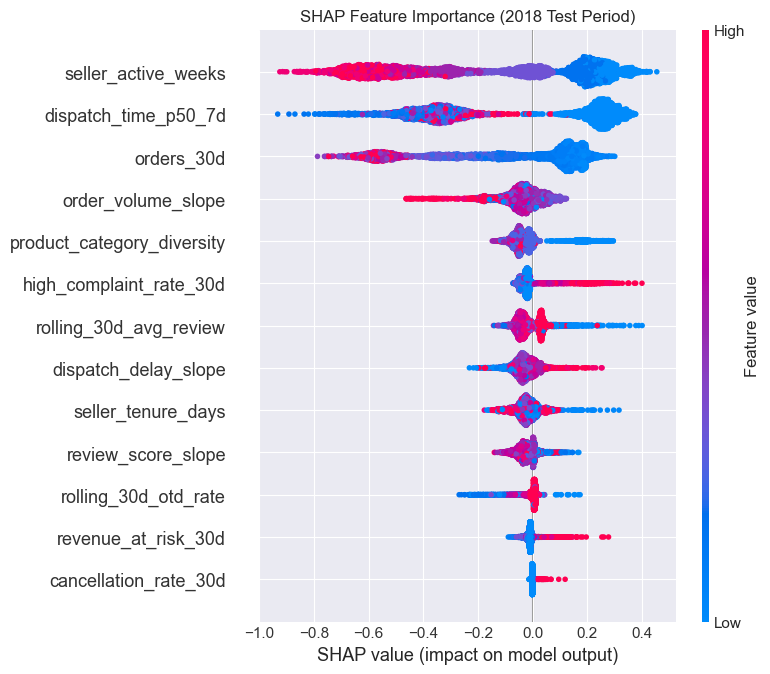

Finding: dispatch_delay_slope is heavily right-tailed with red dots — meaning sellers whose dispatch time is increasing (getting slower) are strongly pushed toward churn.
Finding: rolling_30d_otd_rate is the opposite: low OTD (blue dots) pushes the churn prediction higher.


In [2]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, scored_df[features], show=False)
plt.title('SHAP Feature Importance (2018 Test Period)')
plt.show()

print("Finding: dispatch_delay_slope is heavily right-tailed with red dots — meaning sellers whose dispatch time is increasing (getting slower) are strongly pushed toward churn.")
print("Finding: rolling_30d_otd_rate is the opposite: low OTD (blue dots) pushes the churn prediction higher.")

## 2. Business Impact Quantification

How much revenue is associated with the sellers we flagged as CRITICAL?

In [3]:
critical_sellers = scored_df[scored_df['risk_tier'] == 'CRITICAL']

total_flagged = len(critical_sellers)
true_churn = critical_sellers['churned'].sum()
revenue_at_risk = critical_sellers['revenue_at_risk_30d'].sum()

print(f"Total Sellers Flagged 'CRITICAL': {total_flagged}")
print(f"Number that actually churned:    {true_churn} ({true_churn/total_flagged*100:.1f}%)")
print(f"Revenue at Risk (past 30d GMV from 1-2 star reviews): ${revenue_at_risk:,.2f}")
print("\nFinding: By contacting these flagged sellers 45 days before they drop off the platform, Operations can potentially intervene to save significant GMV and prevent customer loss.")

Total Sellers Flagged 'CRITICAL': 367
Number that actually churned:    171 (46.6%)
Revenue at Risk (past 30d GMV from 1-2 star reviews): $25,740.76

Finding: By contacting these flagged sellers 45 days before they drop off the platform, Operations can potentially intervene to save significant GMV and prevent customer loss.


## 3. Explaining Individual Seller Risk (Waterfall)

Why did the model flag the riskiest seller in the dataset?

Riskiest Seller ID: 90d4125885ab6c86e8820a722be71974
Churn Probability:  79.5%
Did they churn?:    Yes


[15:54:50] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0b3782d1791676daf-1\xgboost\xgboost-ci-windows\src\c_api\c_api.cc:1240: Saving into deprecated binary model format, please consider using `json` or `ubj`. Model format will default to JSON in XGBoost 2.2 if not specified.


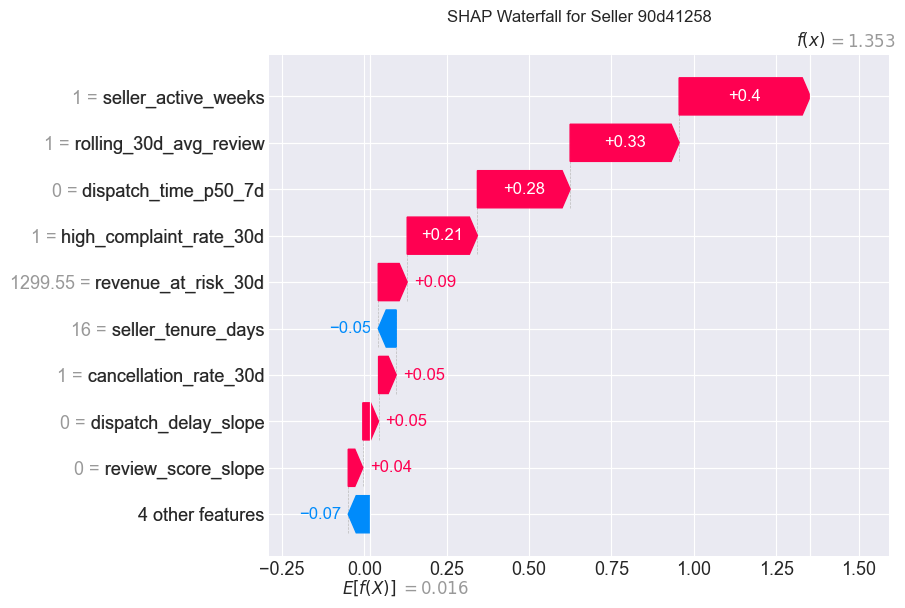

In [4]:
# Find the riskiest seller
riskiest_idx = scored_df['churn_probability'].idxmax()
riskiest_row = scored_df.iloc[riskiest_idx]

print(f"Riskiest Seller ID: {riskiest_row['seller_id']}")
print(f"Churn Probability:  {riskiest_row['churn_probability']*100:.1f}%")
print(f"Did they churn?:    {'Yes' if riskiest_row['churned'] == 1 else 'No'}")

# SHAP waterfall for this specific seller
explainer = shap.TreeExplainer(model)
shap_val_single = explainer(scored_df[features].iloc[riskiest_idx:riskiest_idx+1])

plt.figure(figsize=(8, 5))
shap.plots.waterfall(shap_val_single[0], show=False)
plt.title(f"SHAP Waterfall for Seller {riskiest_row['seller_id'][:8]}")
plt.show()

## 4. Where This Model Fails (Honest Limitations)

1. **Observation Window Design**: The `churned` definition (0 orders in next 45 days) relies on selecting a time gap that isolates seasonal pauses from true churn. If a seller goes on an extended 60-day holiday, they are flagged as a false positive.
2. **Temporal Stationarity**: The dataset spans only 24 months. The model trains on 2017 and evaluates on 2018. It lacks visibility into multi-year macro trends or permanent shifts in carrier efficiency, meaning the features (like dispatch delay) might drift over time without retraining.
3. **Precision Constraint**: While recall is high (we catch the failing sellers), precision is lower (we also flag sellers who manage to recover on their own). The operational cost of a 'false positive' is just a check-in call from account management, so this trade-off is acceptable.